In [1]:
import geopandas as gpd
import pandas as pd

ws1 = gpd.read_file("./sakra_ws1/watershed_utm.shp")
ws2 = gpd.read_file("./sakra_ws2/watershed_utm.shp")
ws3 = gpd.read_file("./sakra_ws3/watershed_utm.shp")
ws4 = gpd.read_file("./sakra_ws4/watershed_utm.shp")

In [2]:
from shapely.geometry import MultiLineString, MultiPolygon, Polygon
import geopandas as gpd
import pandas as pd

def get_exterior_boundary(gdf):
    unified = gdf.geometry.union_all()
    if unified.geom_type == 'Polygon':
        return Polygon(unified.exterior.coords)  # outer ring only, no holes
    elif unified.geom_type == 'MultiPolygon':
        return MultiPolygon([Polygon(p.exterior.coords) for p in unified.geoms])
    else:
        raise ValueError(f"Unexpected geometry type: {unified.geom_type}")

# Validate CRS consistency
watersheds = [ws1, ws2, ws3, ws4]
assert all(ws.crs == watersheds[0].crs for ws in watersheds), "CRS mismatch!"

# Build boundary GeoDataFrames
boundary_gdfs = [
    gpd.GeoDataFrame(geometry=[get_exterior_boundary(ws)], crs=ws.crs)
    for ws in watersheds
]

combined_gdf = pd.concat(boundary_gdfs, ignore_index=True)
combined_gdf.to_file('./exterior_boundary.shp', driver='ESRI Shapefile')

In [3]:
mwses1 = gpd.read_file("./sakra_ws1/microwatersheds.geojson")
mwses2 = gpd.read_file("./sakra_ws2/microwatersheds.geojson")
mwses3 = gpd.read_file("./sakra_ws3/microwatersheds.geojson")
mwses4 = gpd.read_file("./sakra_ws4/microwatersheds.geojson")

mwses = [mwses1, mwses2, mwses3, mwses4]
assert all(mws.crs == mwses[0].crs for mws in mwses), "CRS mismatch!"

# Build boundary GeoDataFrames
boundary_gdfs = [
    gpd.GeoDataFrame(geometry=[get_exterior_boundary(mws)], crs=mws.crs)
    for mws in mwses
]

combined_gdf = pd.concat(boundary_gdfs, ignore_index=True)
combined_gdf.to_file('./exterior_boundary_mwses.shp', driver='ESRI Shapefile')

In [4]:
gpd_ws = gpd.read_file("exterior_boundary.shp")
gpd_mws = gpd.read_file("exterior_boundary_mwses.shp")

# Areas in gpd_ws that is not in gpd_mws
diff = gpd_ws.overlay(gpd_mws, how='difference')


<Axes: >

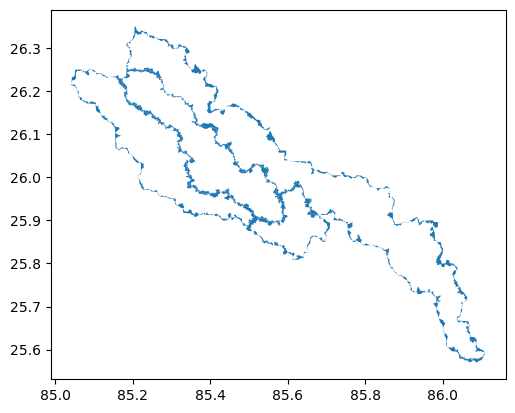

In [7]:
import matplotlib.pyplot as plt
diff_4326 = diff.to_crs(4326)
diff_4326.plot()

In [ ]:
diff_4326.to_file('./diff_delineation.shp', driver='ESRI Shapefile')